# Importación de los datos
Importación del dataset y lectura de sus características

In [183]:
import pandas as pd

DATOS = pd.read_csv("housing.csv")

In [184]:
DATOS.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [185]:
DATOS.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [186]:
DATOS.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [187]:
DATOS.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

GESTIONAR VALORES NULOS

In [188]:
# 2 opciones: Eliminar los valores nulos o replazarlos con la media
data_non_null = DATOS.dropna()
data_non_null.info()

data_clean = DATOS.copy()
data_clean["total_bedrooms"] = data_clean["total_bedrooms"].fillna(value=data_clean["total_bedrooms"].mean())

# Imprimimos para ver si la media cambia:
# Parece que 'total_bedrooms' no cambia (Si cambias los datos nulos por la media no alteras la media global)
# Pero otros valores si pueden cambiar (Si eliminas datos con 'total_bedrooms' nulos, realmente estás borrando
# esa fila de datos entera, por lo que eliminas ese valor del conteo de la media)

print("\ntotal_bedrooms:")
print(f"Media sin valores nulos:  {data_non_null["total_bedrooms"].mean()}")
print(f"Media imputando la media: {data_clean["total_bedrooms"].mean()}")

print("\nhousing_median_age:")
print(f"Media sin valores nulos:  {data_non_null["housing_median_age"].mean()}")
print(f"Media imputando la media: {data_clean["housing_median_age"].mean()}")

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB

total_bedrooms:
Media sin valores nulos:  537.8705525375618
Media imputando la media: 537.8705525375617

housing_median_age:
Media sin valores nulos:  28.633093525179856
Media imputando la media: 28.639486434108527


# Visualización de los datos
Mediante matplotlib y pandas

In [189]:
# Elijo quedarme con el dataframe sin datos nulos (y sin imputación de datos)
data = data_non_null

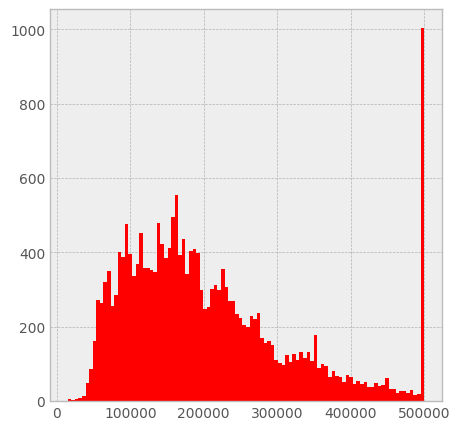

In [190]:
import matplotlib.pyplot as plt 
import numpy as np

plt.style.use('bmh')
fig, ax = plt.subplots(figsize = (4,4)) #crear marco y ejes
x = np.array(data_non_null["median_house_value"]) # Array de Numpy con la columna del valor medio de las 
#casas de cada distrito

ax.hist(x, bins = 100, color = "red") # Histograma de X, con 100 intervalos, de color rojo
plt.show()


In [191]:
# Dibujamos varios gráficos 

def plotGraphs(data, datos_histograma : np.ndarray, 
               titulo_histograma: str, 
               datos_scatter_X,
               datos_scatter_Y, 
               titulo_scatter: str,
               titulo_boxplot: str,
               labels_boxplot: list,
               datos_boxplot,
               titulo_bar: str,
               datos_bar_x,
               ):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), layout="constrained")

    y = np.array(datos_histograma) #y = np.array(data["median_house_value"])
    x = np.arange(len(y)) # x = np.linspace(0, len(y), len(y))

    ax1.set_title(titulo_histograma)
    ax1.hist(y, bins=20, linewidth=0.5, edgecolor="white",color="green")

    ax2.set_title(titulo_scatter)
    ax2.scatter(np.array(datos_scatter_X), np.array(datos_scatter_Y), color="green", alpha = 0.1)
  
    ax3.set_title(titulo_boxplot)
    ax3.set_xticklabels(labels_boxplot)
    ax3.boxplot(np.array(datos_boxplot), showmeans=True, showfliers=True)

    ax4.set_title(titulo_bar)
    x_categorica = datos_bar_x.unique()
    y_categorica = np.array(datos_bar_x.value_counts())
    ax4.bar(x_categorica, y_categorica, linewidth=0.5, color="blue")

    plt.show()
    print("Categóricas:\n", x_categorica, y_categorica)

    print("\nPopulation:")
    print(f"Mean: {datos_boxplot.mean()}, Median: {datos_boxplot.median()}, Min: {datos_boxplot.min()}, Max: {datos_boxplot.max()}")
    print(f"Std: {datos_boxplot.std()}, Var (std^2): {datos_boxplot.var()}")

C:\Users\Av1M1\AppData\Local\Temp\ipykernel_11240\3900326009.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(labels_boxplot)


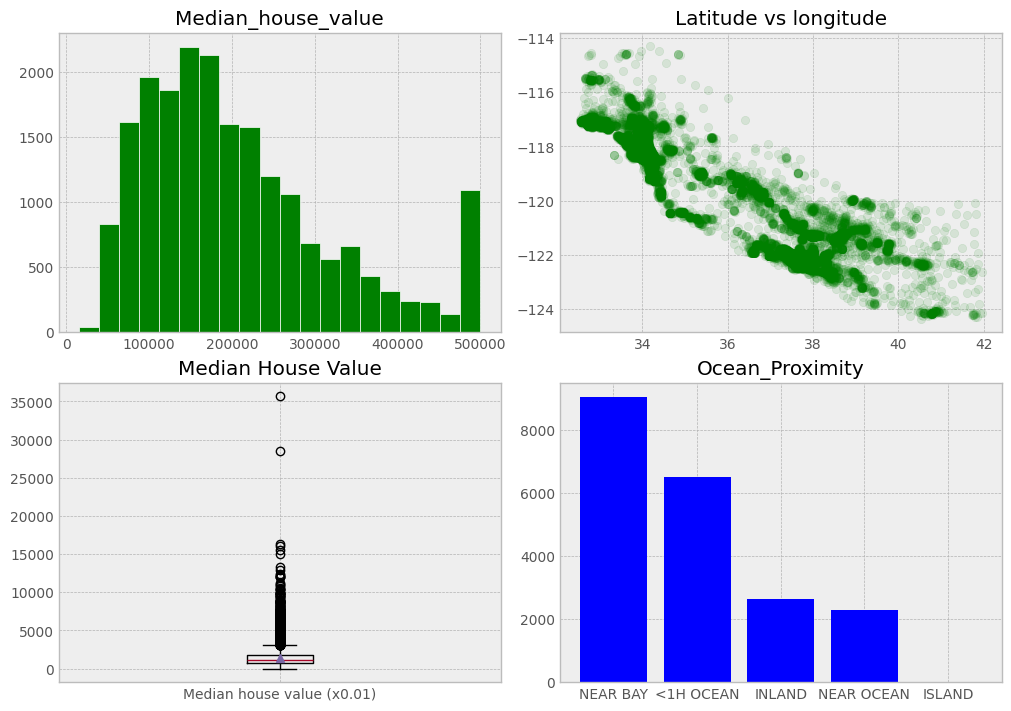

Categóricas:
 <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str [9034 6496 2628 2270    5]

Population:
Mean: 1424.9469485635982, Median: 1166.0, Min: 3.0, Max: 35682.0
Std: 1133.2084897449556, Var (std^2): 1284161.4812300433


In [192]:
plotGraphs(data, data["median_house_value"], "Median_house_value", data["latitude"], data["longitude"], "Latitude vs longitude", 
           "Median House Value", ["Median house value (x0.01)", "Population"], data["population"], "Ocean_Proximity", data["ocean_proximity"])

In [193]:
def plotBoxplots(data, rows=2, cols=5):
    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")

    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 6), layout="constrained")
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.boxplot(data, showmeans=True, showfliers=True)
        
    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()

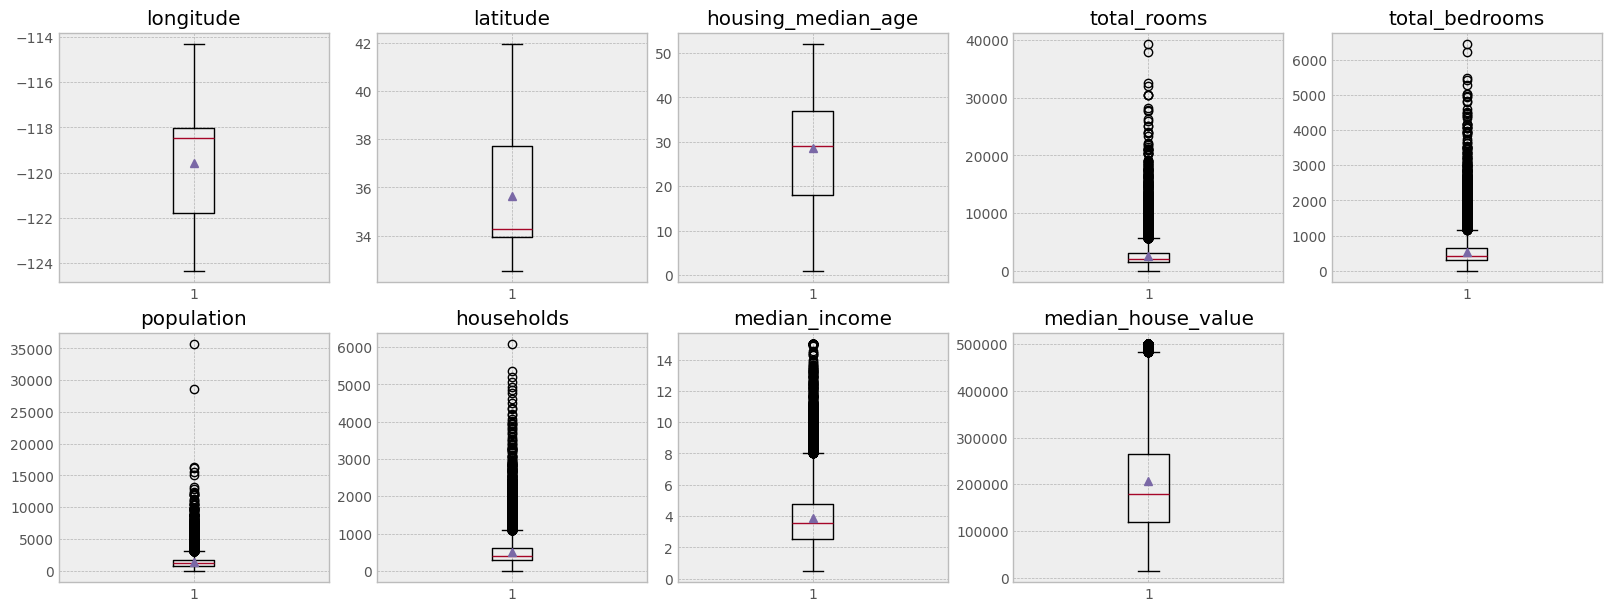

In [194]:
plotBoxplots(data)

mediana:  5.431343939220468
4.441441441441442 6.052380952380952 1.6109395109395104
outliers:  8.468790218790218


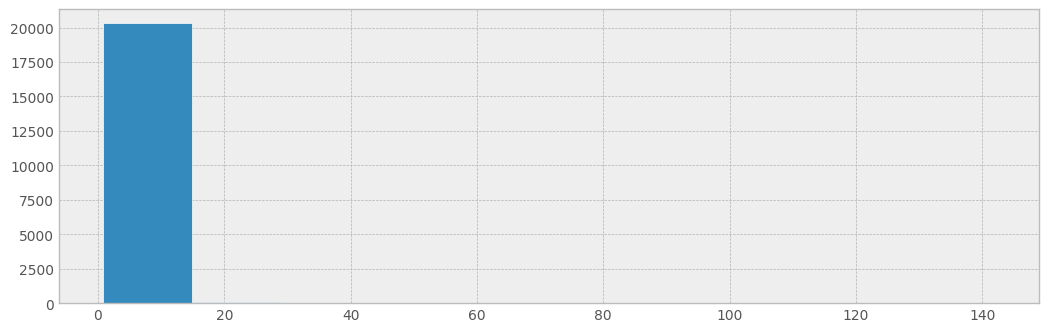

141.9090909090909


In [195]:
# Algunos tests para ver que valores son atípicos y cuales no

habitaciones_por_distrito = data["total_rooms"]/data["households"]
print("mediana: ", habitaciones_por_distrito.mean())

Q1, Q3 = habitaciones_por_distrito.quantile([0.25, 0.75])
rango_intercuartil = Q3 - Q1
print(Q1, Q3, rango_intercuartil)
print("outliers: ", Q3 + rango_intercuartil * 1.5)

fig, ax = plt.subplots(figsize=(10, 3))

x = np.array(habitaciones_por_distrito)

# Dibujamos el historiograma

ax.hist(x, linewidth=0.5, edgecolor="white")
plt.show()
print(habitaciones_por_distrito.max())

También se pueden mostrar gráficos con pandas. Son métodos más sencillos, pero dan menos juego
Además, parece que solo se pueden mostrar de uno en uno (y no en forma de cuadrícula como matplotlib)

<Figure size 200x200 with 0 Axes>

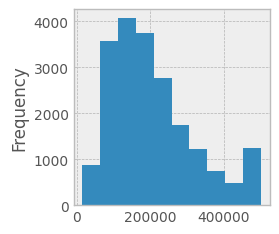

<Figure size 200x200 with 0 Axes>

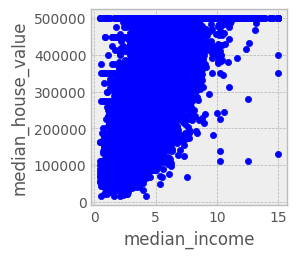

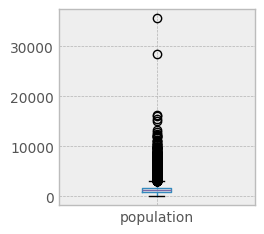

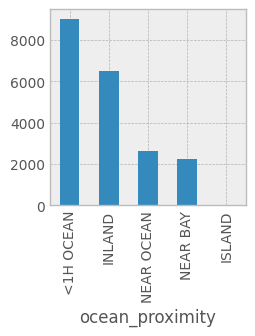

<Figure size 200x200 with 0 Axes>

In [196]:
# Gráficos con pandas
# Gráfico 1
data["median_house_value"].plot.hist()
plt.figure()

# Gráfico 2
data.plot.scatter(x="median_income", y="median_house_value")
plt.figure()

# Gráfico 3
data.boxplot(column="population", grid=True)
plt.figure()

# Gráfico 4
data["ocean_proximity"].value_counts().plot.bar()
plt.figure() # El último se puede omitir con pandas

### Eliminación de valores atípicos
Para cada variable, miramos cada uno de sus valores y eliminamos los que estén por muy alejados de la media (1.5 * RangoIntercuartil)

ERROR: Hay valores que, aunque están alejados de la mediana, no deberían considerarse *outliers*
Quizá hay que preprocesar algunas columnas de datos antes de aplicar el "algoritmo" de eliminación de outliers

In [197]:
# También podemos visualizar los datos
# plotGraphs(data)
# plotGraphs(data_sin_outliers)

Creación de variables relativas

In [198]:
DATOS.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


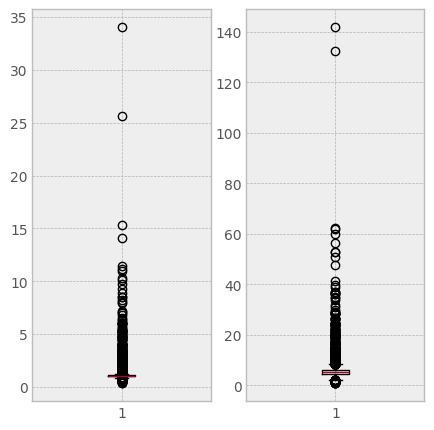

In [199]:
Bedrooms_entre_casa = data_non_null["total_bedrooms"]/data_non_null["households"]
rooms_entre_casa = data_non_null["total_rooms"]/data_non_null["households"]

fig, (ax1, ax2) = plt.subplots(nrows= 1, ncols=2, figsize=(4,4))

ax1.boxplot(Bedrooms_entre_casa)
ax2.boxplot(rooms_entre_casa)

plt.show()

Interpretación: Aun con variables relativas, usando IQR los boxplots marcan una cantidad de valores atípicos muy elevada, lo que significa que no son valores atípicos, sino un reflejo de la naturaleza de los datos.
El hecho de que el número de dormitorios/casa y el número de cuartos/casa sea así quiere decir que tenemos diferentes tipos de casas. Quizá hay zonas con distritos compuestos por casas para una familia mientras que hay otros distritos formadas por bloques de pisos, por lo tanto, no debemos eliminar esos datos ya que son representativos o al menos no por esa razón.
Para ver si son valores atípicos de verdad, vamos a ver si no siguen la distribución del resto de datos

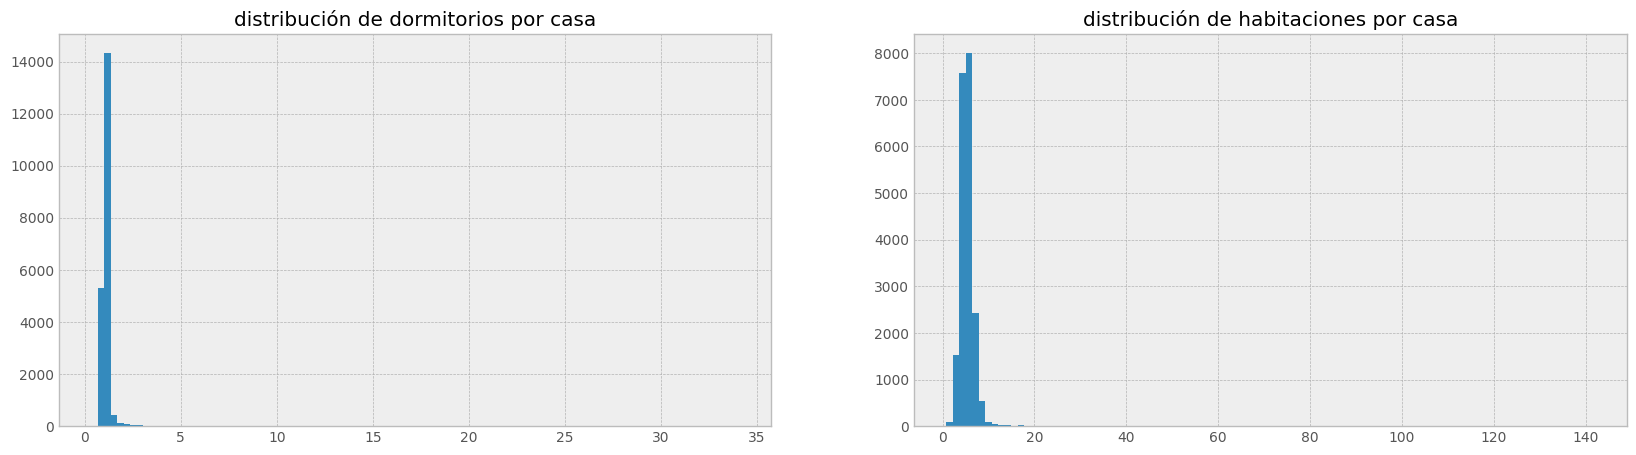

count    20433.000000
mean         1.097062
std          0.476104
min          0.333333
25%          1.006029
50%          1.048889
75%          1.099631
max         34.066667
dtype: float64

In [200]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols= 2, figsize=(16,4))

ax1.hist(Bedrooms_entre_casa,bins=100, linewidth=0.5)
ax1.set_title("distribución de dormitorios por casa")
ax2.hist(rooms_entre_casa,bins=100, linewidth=0.5)
ax2.set_title("distribución de habitaciones por casa")

plt.show()

Bedrooms_entre_casa.describe()

<class 'pandas.DataFrame'>
Index: 19205 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              19205 non-null  float64
 1   latitude               19205 non-null  float64
 2   housing_median_age     19205 non-null  float64
 3   total_rooms            19205 non-null  float64
 4   total_bedrooms         19205 non-null  float64
 5   population             19205 non-null  float64
 6   households             19205 non-null  float64
 7   median_income          19205 non-null  float64
 8   median_house_value     19205 non-null  float64
 9   ocean_proximity        19205 non-null  str    
 10  bedrooms_per_casa      19205 non-null  float64
 11  habitaciones_per_casa  19205 non-null  float64
dtypes: float64(11), str(1)
memory usage: 1.9 MB
<class 'pandas.DataFrame'>
Index: 19067 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                 Non-Null 

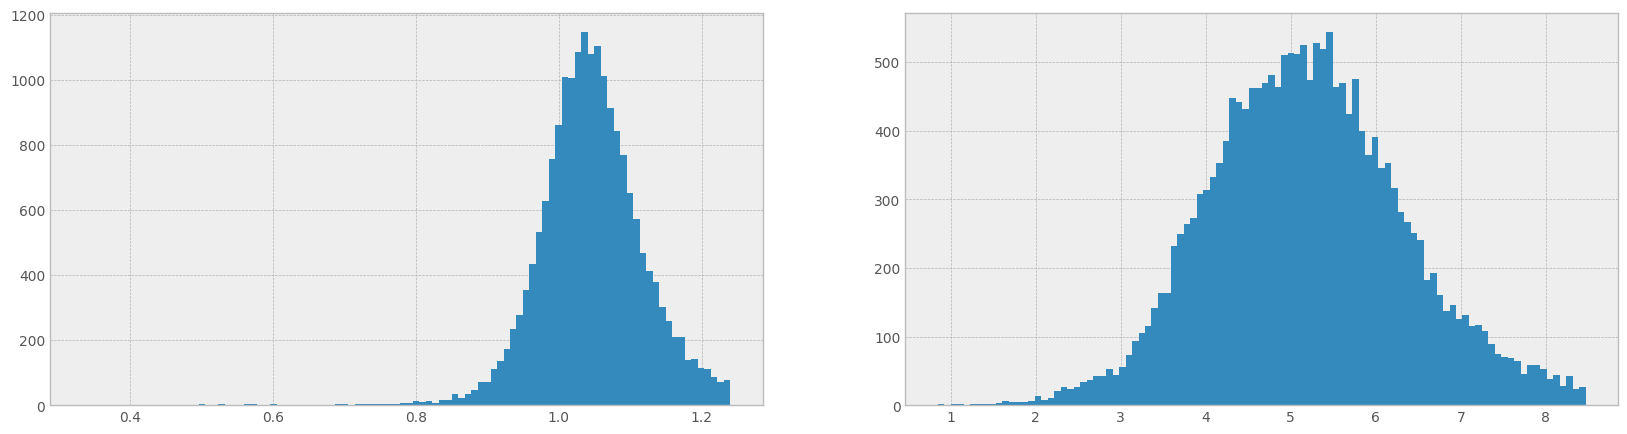

In [201]:
data["bedrooms_per_casa"] = Bedrooms_entre_casa
data["habitaciones_per_casa"] = rooms_entre_casa

Q1, Q3 = Bedrooms_entre_casa.quantile([0.25, 0.75])
IQR = Q3-Q1
limite_superior = Q3+IQR*1.5
data = data[data["bedrooms_per_casa"] < limite_superior]
data.info()


Q1, Q3 = rooms_entre_casa.quantile([0.25, 0.75])
IQR = Q3-Q1
limite_superior = Q3+IQR*1.5
data = data[data["habitaciones_per_casa"] < limite_superior]


fig, (ax1,ax2) = plt.subplots(nrows=1, ncols= 2, figsize = (16,4))
ax1.hist(np.array(data["bedrooms_per_casa"]), bins = 100)
ax2.hist(np.array(data["habitaciones_per_casa"]), bins = 100)

data.info()

plt.show()

## Gestión de datos erróneos en Median_House_Value

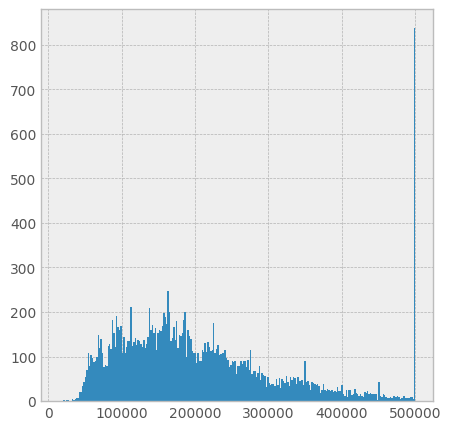

In [202]:
fig, ax = plt.subplots(figsize=(4,4))
x = np.array(data["median_house_value"])

ax.hist(x, bins=250)
plt.show()

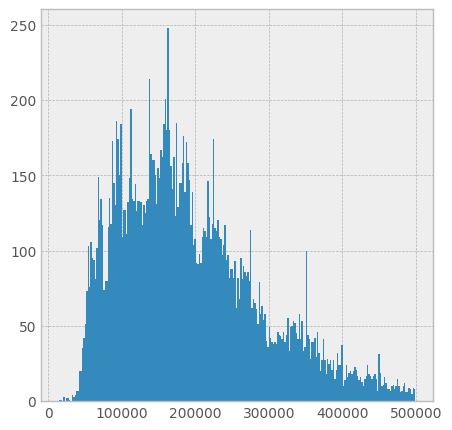

<class 'pandas.DataFrame'>
Index: 18235 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              18235 non-null  float64
 1   latitude               18235 non-null  float64
 2   housing_median_age     18235 non-null  float64
 3   total_rooms            18235 non-null  float64
 4   total_bedrooms         18235 non-null  float64
 5   population             18235 non-null  float64
 6   households             18235 non-null  float64
 7   median_income          18235 non-null  float64
 8   median_house_value     18235 non-null  float64
 9   ocean_proximity        18235 non-null  str    
 10  bedrooms_per_casa      18235 non-null  float64
 11  habitaciones_per_casa  18235 non-null  float64
dtypes: float64(11), str(1)
memory usage: 1.8 MB


In [208]:
data = data[data["median_house_value"]<499999] #eliminamos las casas acumuladas en 500000$

fig, ax = plt.subplots(figsize=(4,4))
x = np.array(data["median_house_value"])

ax.hist(x, bins=250)
plt.show()

data.info()

## Discriminación de datos más correlacionados con la variable target

## Gestión de data Leakage

# Notas aparte

In [204]:
# NOTAS APARTE
# house = data.iloc[i, :] # Para mirar casa por casa